In [111]:
import pandas as pd # data preprocessing
import matplotlib.pyplot as plt # Data visualization
import seaborn as sns # data visualization
import missingno as msno # missing data - data visualization
from collections import Counter # counting
import numpy as np 

In [112]:
# Data Pre-Processing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Classifier Libraries 
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


#!pip install xgboost
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [113]:
from sklearn.neighbors import KNeighborsClassifier# load dataset
df = pd.read_csv(r"C:\Users\DELL-PC\OneDrive\Desktop\Nebiant\Intenship project 2 cleaned.csv")

In [114]:
df.head()

,city,order_ id,order_date,store_ Code,basket_ size,delivery_ Fee,cost_per_order,distance_km (pick up to delivery),courier_wait_time (mins)
0,BCN,1,28-Jun-25,66944,11.5,2.1,3.9,1.7,3.8
1,BCN,2,28-Jun-25,74118,18.8,3.3,3.3,2.7,1.4
2,BCN,3,28-Jun-25,65231,18.4,2.1,3.4,1.6,3.4
3,MAD,4,28-Jun-25,205036,3.3,1.2,1.8,0.3,3.2
4,MAD,5,28-Jun-25,34310,15.7,1.5,2.4,0.6,2.8


In [115]:
df.shape

(1119, 9)

In [116]:
df.columns

Index(['city', 'order_ id', 'order_date', 'store_ Code', 'basket_ size',
       'delivery_ Fee', 'cost_per_order', 'distance_km (pick up to delivery)',
       'courier_wait_time (mins)'],
      dtype='object')

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   city                               1119 non-null   object 
 1   order_ id                          1119 non-null   int64  
 2   order_date                         1119 non-null   object 
 3   store_ Code                        1119 non-null   int64  
 4   basket_ size                       1119 non-null   float64
 5   delivery_ Fee                      1119 non-null   float64
 6   cost_per_order                     1119 non-null   float64
 7   distance_km (pick up to delivery)  1119 non-null   float64
 8   courier_wait_time (mins)           1119 non-null   float64
dtypes: float64(5), int64(2), object(2)
memory usage: 78.8+ KB


In [118]:
# Numerical column
df.describe()

,order_ id,store_ Code,basket_ size,delivery_ Fee,cost_per_order,distance_km (pick up to delivery),courier_wait_time (mins)
count,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000
mean,560.000000,133072.367292,15.656568,1.959428,3.531725,1.488204,3.776497
std,323.171781,91552.226607,5.015529,0.661879,0.913232,0.807857,1.536110
min,1.000000,7053.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.500000,65231.000000,12.000000,1.500000,3.000000,0.850000,2.900000
50%,560.000000,74119.000000,16.900000,1.900000,3.500000,1.400000,3.700000
75%,839.500000,248266.000000,19.200000,2.300000,3.900000,1.900000,4.400000
max,1119.000000,264652.000000,37.100000,4.500000,10.900000,5.500000,17.100000


In [119]:
# Categorical column
df.describe(include =['object', 'bool'])

,city,order_date
count,1119,1119
unique,2,89
top,BCN,13-May-25
freq,589,14


In [120]:
# check for Missing data
null_vals = df.isnull().sum()
null_vals

city                                 0
order_ id                            0
order_date                           0
store_ Code                          0
basket_ size                         0
delivery_ Fee                        0
cost_per_order                       0
distance_km (pick up to delivery)    0
courier_wait_time (mins)             0
dtype: int64

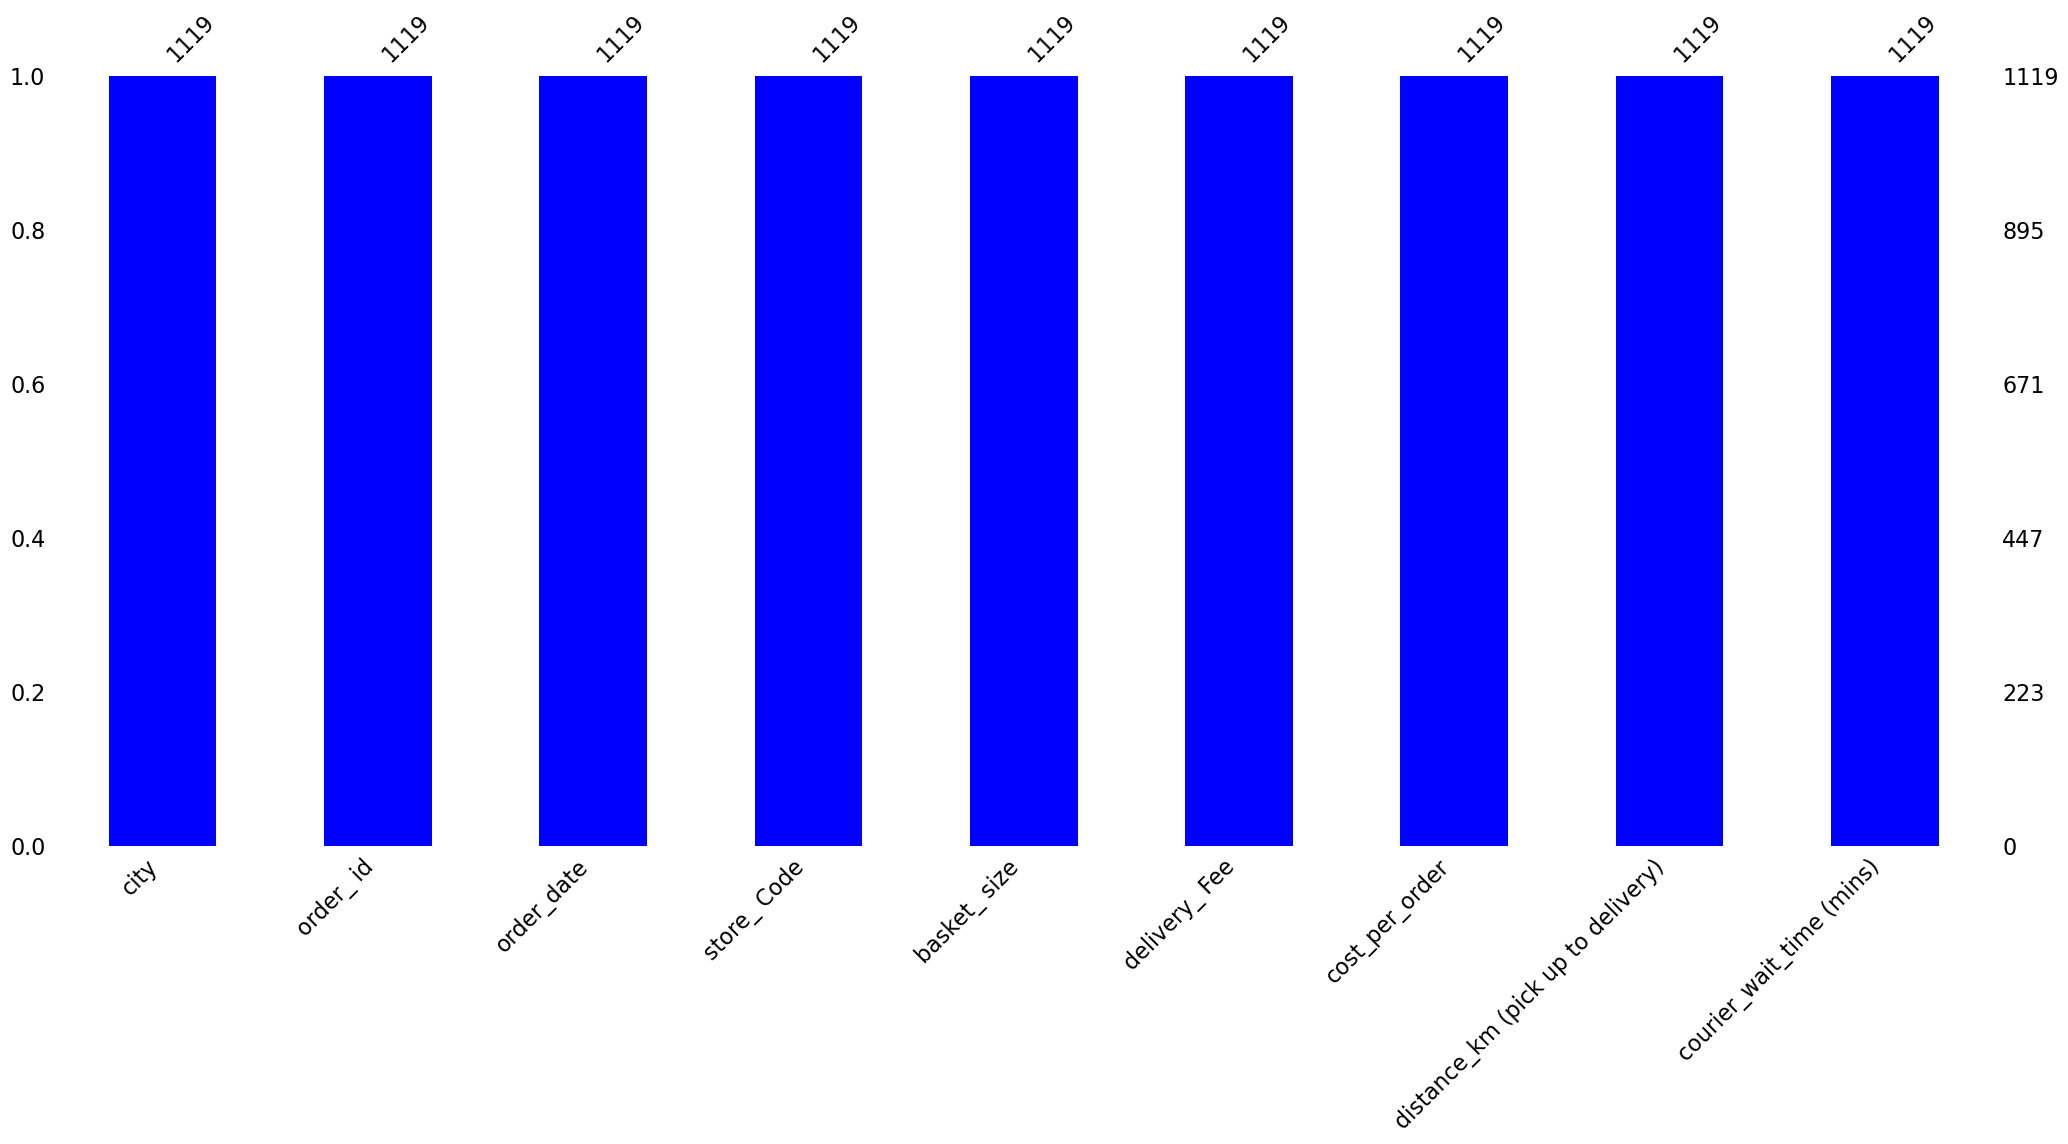

In [121]:
#visualizingthe missing data with bar plot
msno.bar(df, color = "Blue");

In [122]:
#df.describe(exclude = ["integer","float"])
df.describe(exclude = np.number).T

,count,unique,top,freq
city,1119,2,BCN,589
order_date,1119,89,13-May-25,14


In [123]:
# Step 1: Data Preparation 

df.columns = df.columns.str.lower().str.replace("_", " ").str.replace("(","").str.replace(")", "")


In [124]:
df = df.rename(columns={
    'distance_km_pick_up_to_delivery':'distance_km' # Rename column
})

In [125]:
# Convert Date
df['order date'] = pd.to_datetime(df['order date'])

#### OVERVIEW OF DATA - UNIVARIATE ANALYSIS

In [126]:
df.describe()

,order id,order date,store code,basket size,delivery fee,cost per order,distance km pick up to delivery,courier wait time mins
count,1119.000000,1119,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000,1119.000000
mean,560.000000,2025-05-14 22:45:21.715817728,133072.367292,15.656568,1.959428,3.531725,1.488204,3.776497
min,1.000000,2025-04-01 00:00:00,7053.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.500000,2025-04-23 00:00:00,65231.000000,12.000000,1.500000,3.000000,0.850000,2.900000
50%,560.000000,2025-05-14 00:00:00,74119.000000,16.900000,1.900000,3.500000,1.400000,3.700000
75%,839.500000,2025-06-06 00:00:00,248266.000000,19.200000,2.300000,3.900000,1.900000,4.400000
max,1119.000000,2025-06-28 00:00:00,264652.000000,37.100000,4.500000,10.900000,5.500000,17.100000
std,323.171781,NaN,91552.226607,5.015529,0.661879,0.913232,0.807857,1.536110


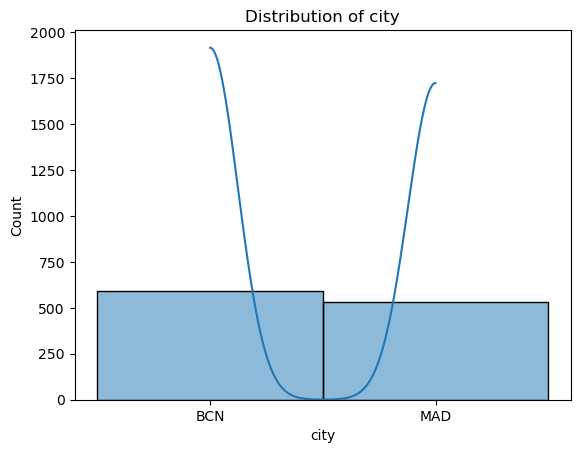

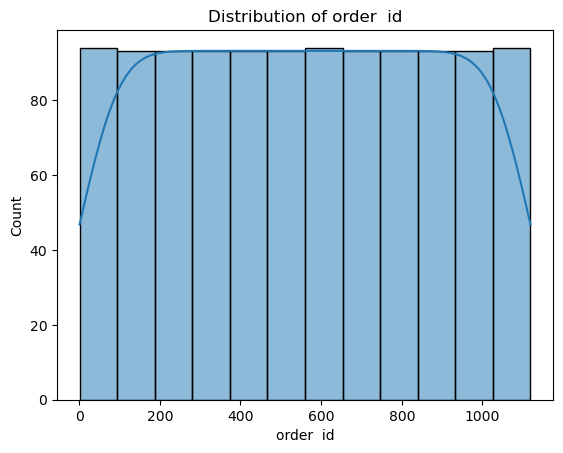

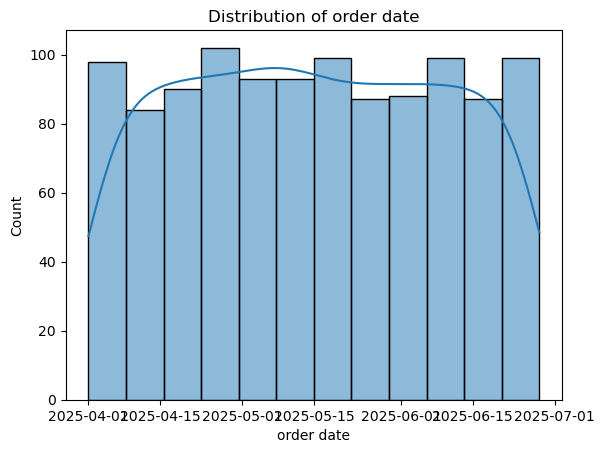

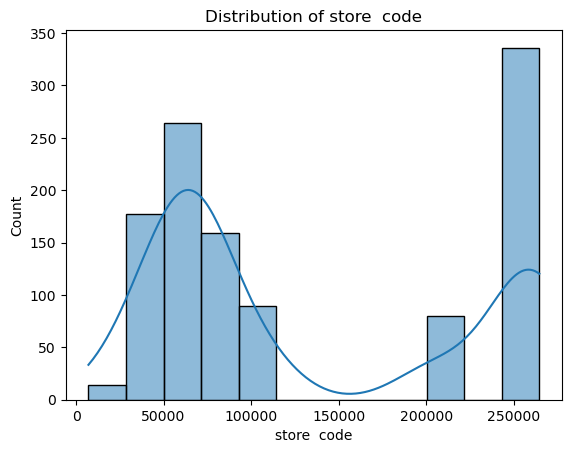

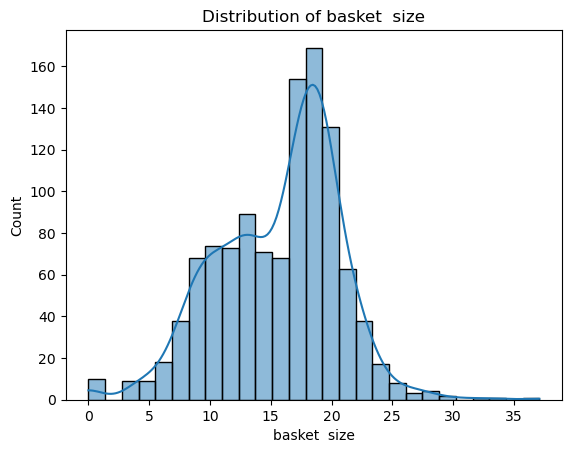

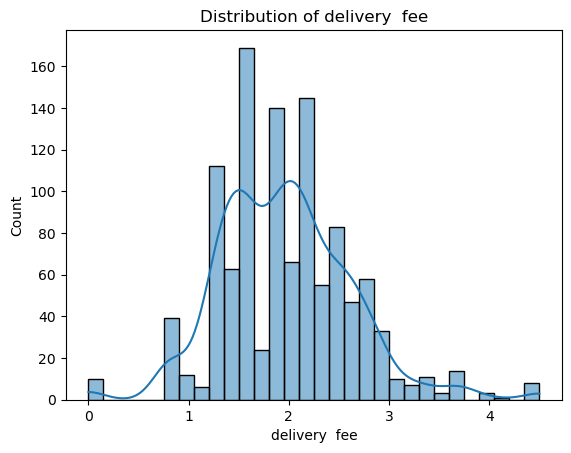

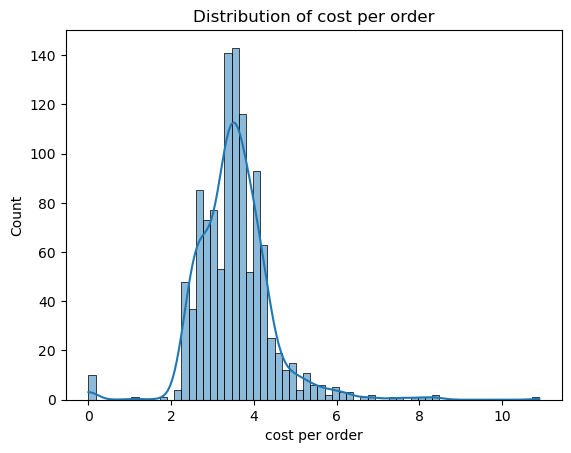

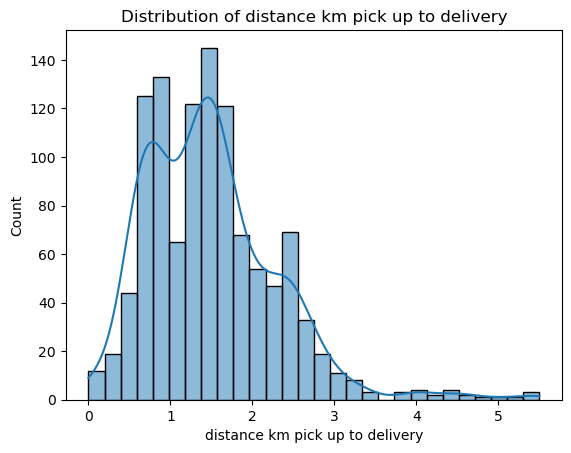

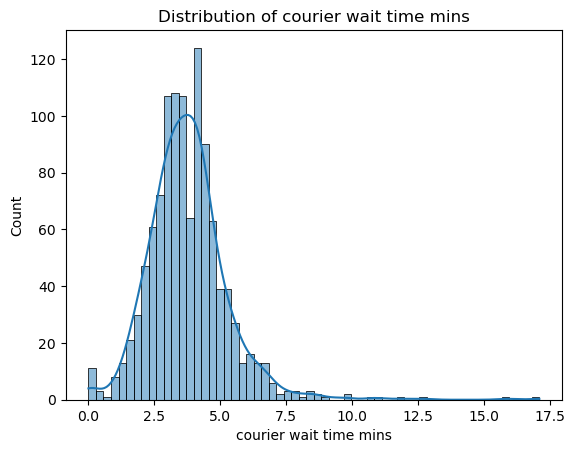

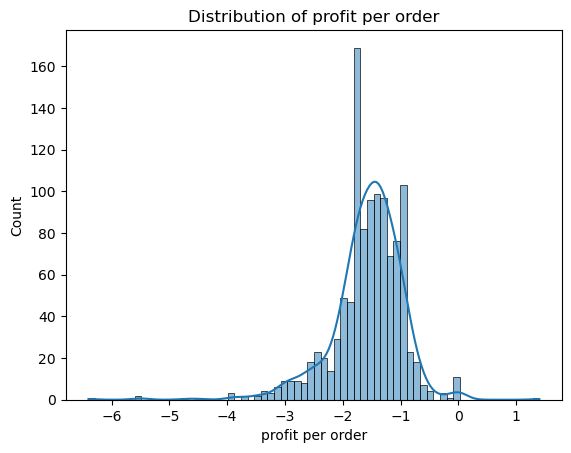

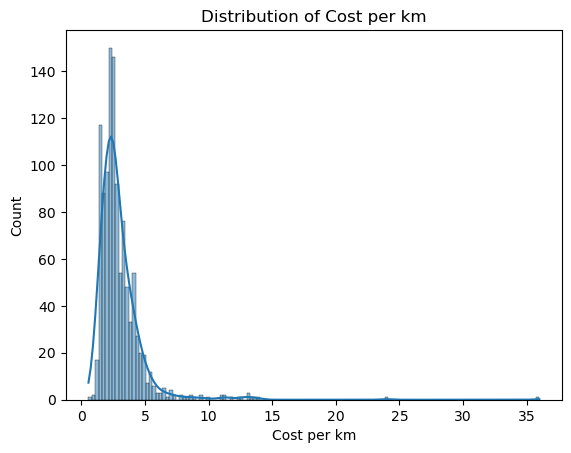

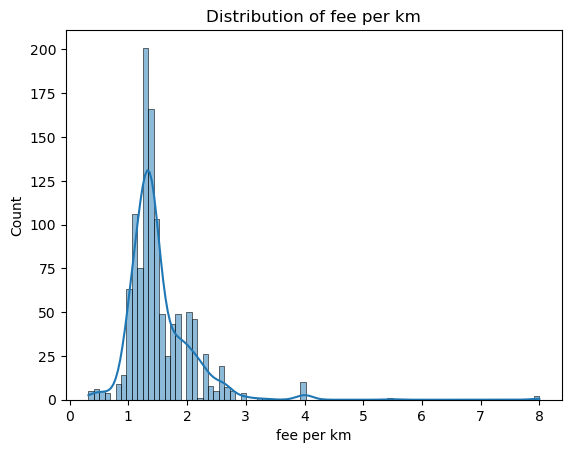

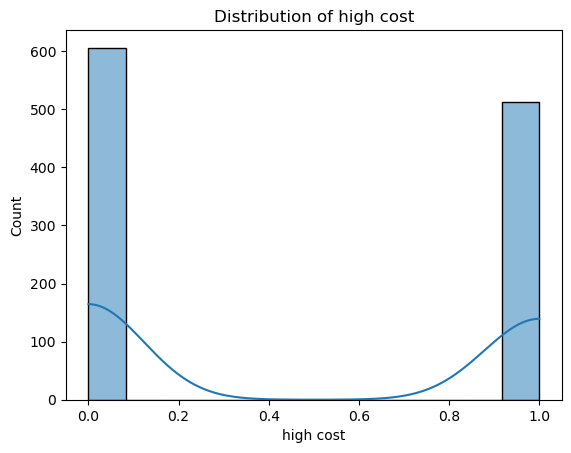

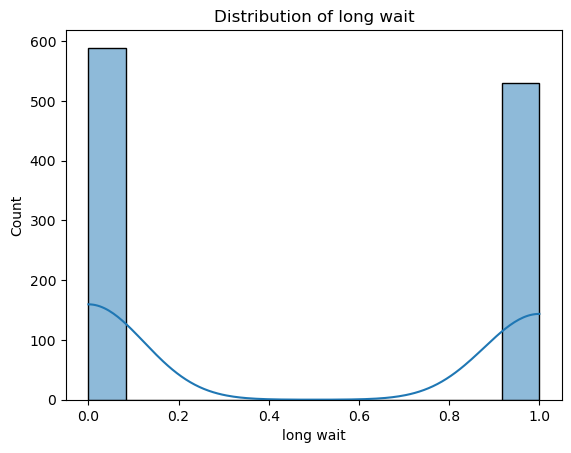

In [61]:
# Distribution plots

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['basket size','delivery fee','cost per order','distance km', 'courier wait time']
for col in df.columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
    

In [62]:
## is cost per order skewed, are there extreem waiting times


#### 0.29 is a weak positive correlation btw distance and courier waiting time. This implies that as delivery distance increases waiting time may increase slightly. but distance is not the major reason for waiting. 

## Bivariate Analysis:

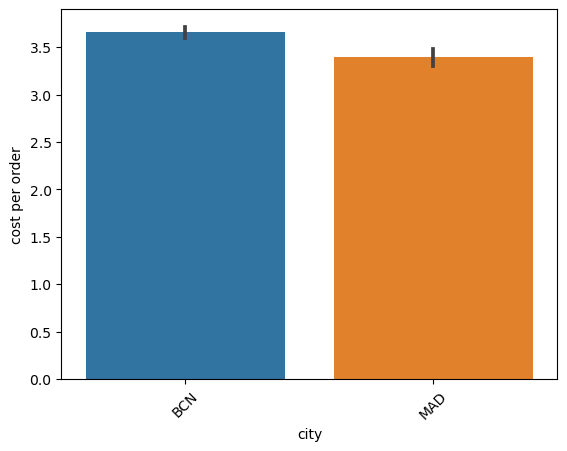

In [129]:
 ### Which cities have highesst CPO

df.groupby('city')['cost per order'].mean().sort_values(ascending=False)

### Plot
plt.figure()
sns.barplot(x='city', y='cost per order', data=df)
plt.xticks(rotation=45)
plt.show()

#### Insight: The BCN city is more expensive to run

In [130]:
df.groupby('city')['cost per order'].mean().sort_values(ascending=False)

city
BCN    3.656537
MAD    3.393019
Name: cost per order, dtype: float64

In [131]:
df.head()

,city,order id,order date,store code,basket size,delivery fee,cost per order,distance km pick up to delivery,courier wait time mins
0,BCN,1,2025-06-28,66944,11.5,2.1,3.9,1.7,3.8
1,BCN,2,2025-06-28,74118,18.8,3.3,3.3,2.7,1.4
2,BCN,3,2025-06-28,65231,18.4,2.1,3.4,1.6,3.4
3,MAD,4,2025-06-28,205036,3.3,1.2,1.8,0.3,3.2
4,MAD,5,2025-06-28,34310,15.7,1.5,2.4,0.6,2.8


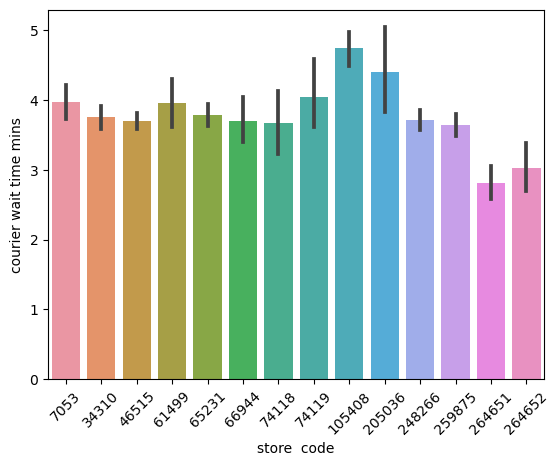

In [132]:
#### Q2: Which stores have highest waiting time

df.groupby ('store  code')['courier wait time mins'].mean().sort_values(ascending=False).head(10)

### Plot
plt.figure()
sns.barplot(x='store  code', y='courier wait time mins', data=df)
plt.xticks(rotation=45)
plt.show()

####  Insight: Store code 105408 have the longest waiting times. which indicates operational inefficiency at that store.
#### Possibly reason include - Slow food preparation, staff shortage, high order volume, poor coordination btw store and courier or order not ready when courier arrives 

In [133]:
df.columns

Index(['city', 'order  id', 'order date', 'store  code', 'basket  size',
       'delivery  fee', 'cost per order', 'distance km pick up to delivery',
       'courier wait time mins'],
      dtype='object')

<Axes: xlabel='distance km pick up to delivery', ylabel='cost per order'>

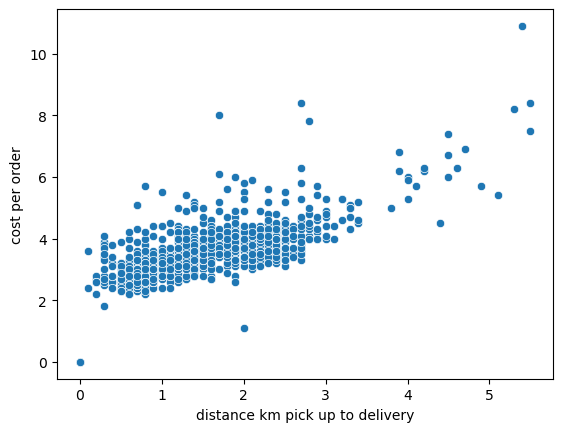

In [134]:
### Distance vs CPO
sns.scatterplot(x='distance km pick up to delivery', y='cost per order', data=df)



In [135]:
df[['distance km pick up to delivery','cost per order']].corr()

,distance km pick up to delivery,cost per order
distance km pick up to delivery,1.000000,0.739205
cost per order,0.739205,1.000000


###### Correlation 0.74 is a strong positive correlation, which implies that, the farther the delivery distance, the higher the cost per order. So Distance is a major cost driver

<Axes: xlabel='basket  size', ylabel='cost per order'>

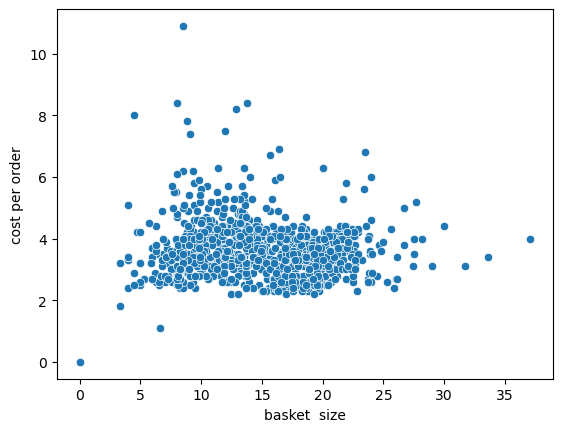

In [136]:
#### Basket Size vs CPO
sns.scatterplot(x='basket  size', y='cost per order', data=df)

In [137]:
df[['basket  size','cost per order']].corr()

,basket size,cost per order
basket size,1.000000,-0.015118
cost per order,-0.015118,1.000000


####  -0.015 correlation implies almost no relationship between them. i.e
#### Basket size does not affect the cost per order. Delivery cost is independent of how many items the customer order.

<Axes: xlabel='courier wait time mins', ylabel='distance km pick up to delivery'>

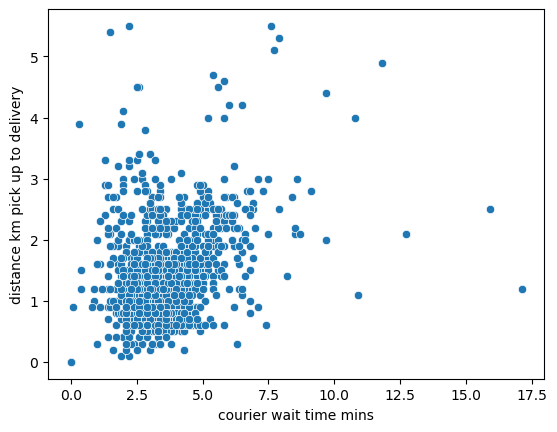

In [138]:
#### Waitng time vs Distance
sns.scatterplot(x='courier wait time mins', y='distance km pick up to delivery', data=df)

In [139]:
df[['courier wait time mins','distance km pick up to delivery',]].corr()

,courier wait time mins,distance km pick up to delivery
courier wait time mins,1.000000,0.290242
distance km pick up to delivery,0.290242,1.000000


#### 0.29 is a weak positive correlation btw distance and courier waiting time. This implies that as delivery distance increases waiting time may increase slightly. but distance is not the major reason for cuorier waiting.

### Multivariate Analysis

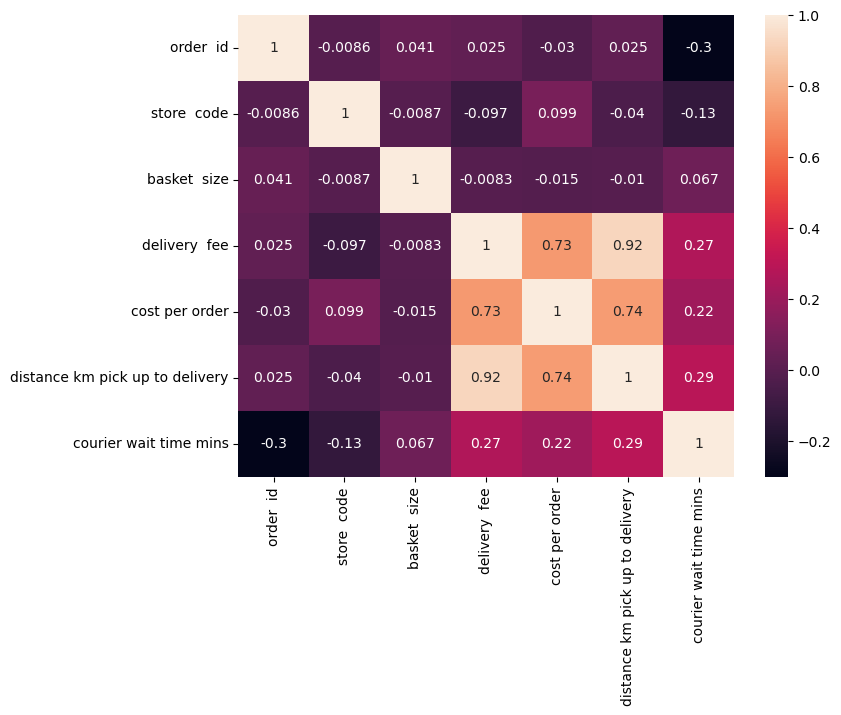

In [140]:
#### Corellation Heatmap

plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

#### Key findings : cost per order vs distance km pick up time = 0.74
#### -courier wait time vs distance = 0.29
#### -courier wait time vs basket size = 0.06

In [155]:
df.head()

,city,order id,order date,store code,basket size,delivery fee,cost per order,distance km pick up to delivery,courier wait time mins
0,BCN,1,2025-06-28,66944,11.5,2.1,3.9,1.7,3.8
1,BCN,2,2025-06-28,74118,18.8,3.3,3.3,2.7,1.4
2,BCN,3,2025-06-28,65231,18.4,2.1,3.4,1.6,3.4
3,MAD,4,2025-06-28,205036,3.3,1.2,1.8,0.3,3.2
4,MAD,5,2025-06-28,34310,15.7,1.5,2.4,0.6,2.8


### Feature Engineering

In [156]:
#### 1. Profit per Order

df['profit per order'] =df['delivery  fee'] - df['cost per order']
df['profit per order']

0      -1.8
1       0.0
2      -1.3
3      -0.6
4      -0.9
       ... 
1114   -2.0
1115   -1.2
1116   -1.1
1117   -1.2
1118   -1.6
Name: profit per order, Length: 1119, dtype: float64

#### PPO is negative: Losing money


In [157]:
#### 2. Cost per KM
df['Cost per km'] = df['cost per order'] / df['distance km pick up to delivery']
df['Cost per km'].head

<bound method NDFrame.head of 0       2.294118
1       1.222222
2       2.125000
3       6.000000
4       4.000000
          ...   
1114    2.625000
1115    6.000000
1116    3.250000
1117    1.947368
1118    3.333333
Name: Cost per km, Length: 1119, dtype: float64>

In [158]:
#### 3. Fee per KM

df['fee per km'] =df['delivery  fee'] / df['distance km pick up to delivery']
df['fee per km']

0       1.235294
1       1.222222
2       1.312500
3       4.000000
4       2.500000
          ...   
1114    1.375000
1115    3.000000
1116    1.875000
1117    1.315789
1118    1.555556
Name: fee per km, Length: 1119, dtype: float64

In [159]:
df['Cost per km']- df['fee per km'] ## if cpk>fpk its pricing problem

0       1.058824
1       0.000000
2       0.812500
3       2.000000
4       1.500000
          ...   
1114    1.250000
1115    3.000000
1116    1.375000
1117    0.631579
1118    1.777778
Length: 1119, dtype: float64

In [160]:
#### High Cost Flag (For Prediction)

df['high cost'] = (df['cost per order'] > df['cost per order'].mean()).astype(int)
df['high cost']

0       1
1       0
2       0
3       0
4       0
       ..
1114    1
1115    0
1116    0
1117    1
1118    0
Name: high cost, Length: 1119, dtype: int32

In [161]:
#### Long wait Flag 

df['long wait'] = (df['courier wait time mins'] > df['courier wait time mins'].mean()).astype(int)
df['long wait']

0       1
1       0
2       0
3       0
4       0
       ..
1114    0
1115    0
1116    0
1117    1
1118    0
Name: long wait, Length: 1119, dtype: int32

## Model 1: Predict High Cost Orders

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['distance km pick up to delivery', 'basket  size', 'delivery  fee','courier wait time mins']]
y = df['high cost']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.7901785714285714


In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [166]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X = df[['distance km pick up to delivery', 'basket  size', 'delivery  fee','courier wait time mins']]
y = df['high cost']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model =  KNeighborsClassifier()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.7410714285714286


In [165]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df[['distance km pick up to delivery', 'basket  size', 'delivery  fee','courier wait time mins']]
y = df['high cost']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.7321428571428571


In [167]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['distance km pick up to delivery', 'basket  size', 'delivery  fee','courier wait time mins']]
y = df['high cost']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.7276785714285714


In [170]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['distance km pick up to delivery', 'basket  size', 'delivery  fee','courier wait time mins']]
y = df['high cost']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print(model.score(X_test, y_test))

0.7901785714285714


## Feature Importance / Model Building

In [223]:
# Train the model e.g with Random Forest, define your X and y correctly

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

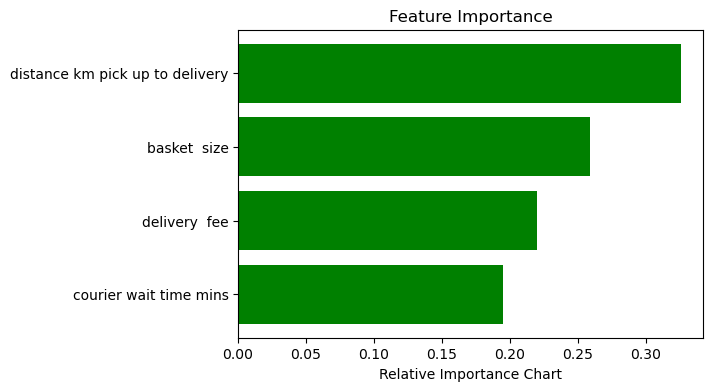

In [228]:
# Plotting a feature importance chart
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

importances  = model.feature_importances_ # Get features importance
names = X.columns

sort_imp = np.argsort(importances) # Sort the importance

plt.figure(figsize = (6,4))
plt.barh(range(len(sort_imp)),
         importances[sort_imp], color="green")
plt.yticks(range(len(sort_imp)),
            [names[i] for i in sort_imp])
plt.title("Feature Importance")
plt.xlabel("Relative Importance Chart")
plt.show()
                                               
                                              


## Model Prediction

### Model B : Build Model B to Predict Long Waiting Time (Classification)

##### Convert wait time into a classification variable  using (5mins)
##### 1 = long wait 
##### 0 = Normal wait




In [244]:
df['long wait'] = (df['courier wait time mins'] > 5).astype(int)
df['long wait']

0       0
1       0
2       0
3       0
4       0
       ..
1114    0
1115    0
1116    0
1117    1
1118    0
Name: long wait, Length: 1119, dtype: int32

In [277]:
#### Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,y, test_size=0.2, random_state=42)

In [278]:
classifiers = [
    [SVC(), "SVC"],
    [RandomForestClassifier(), "Random Forest"],
    [LogisticRegression(), "Logistic Regression"],
    [XGBClassifier(), "XGB Classifiers"],
    [SGDClassifier(), "SGD Classifier" ],
    [GaussianNB(), "Naive Bayes"],
    [DecisionTreeClassifier(), "Decision Tree"]
]

In [279]:
from sklearn.model_selection import GridSearchCV

In [281]:
from sklearn.metrics import classification_report, confusion_matrix
acc_list = {}
f_list = {}
roc_list = {}
precision_list = {}
recall_list = {}
confusion_matrix_list = {}

for classifier in classifiers:
    model = classifier[0]
    model.fit(X_train, y_train)
    model_name = classifier[1]
    
    X_test_contiguous = np.ascontiguousarray(X_test)
    y_pred = model.predict(X_test_contiguous)
    a_score = accuracy_score(y_test, y_pred)
    f_score = f1_score(y_test, y_pred)
    roc_score = roc_auc_score(y_test, y_pred)
    p_score = precision_score(y_test, y_pred)
    r_score = recall_score(y_test, y_pred)
    confusion_matrix_score = confusion_matrix(y_test, y_pred)
    tn,fp,tn,tp = confusion_matrix_score.ravel()
    confusion_matrix_list.update({model_name: confusion_matrix_score})
    
    
    print(f"\n Classifier: {model_name}")
    print(f"Accuracy: {a_score*100:.2f}%")
    print(f"F1 Score: {f_score*100:.2f}%")
    print(f"ROC AUC: {roc_score*100:.2f}%")
    print(f"Precision: {p_score*100:.2f}%")
    print(f"Recall: {r_score*100:.2f}%")
    print("Confusion  Matrix:")
    print(pd.DataFrame(confusion_matrix_score / confusion_matrix_score.sum(axis=1)[:, np.newaxis]*100).round(2).to_string(formatters={'float': lambda  x: f"{x:.2f}%"}))


 Classifier: SVC
Accuracy: 74.11%
F1 Score: 68.82%
ROC AUC: 73.13%
Precision: 74.42%
Recall: 64.00%
Confusion  Matrix:
       0      1
0  82.26  17.74
1  36.00  64.00

 Classifier: Random Forest
Accuracy: 77.68%
F1 Score: 75.00%
ROC AUC: 77.42%
Precision: 75.00%
Recall: 75.00%
Confusion  Matrix:
       0      1
0  79.84  20.16
1  25.00  75.00

 Classifier: Logistic Regression
Accuracy: 72.77%
F1 Score: 68.39%
ROC AUC: 72.11%
Precision: 70.97%
Recall: 66.00%
Confusion  Matrix:
       0      1
0  78.23  21.77
1  34.00  66.00

 Classifier: XGB Classifiers
Accuracy: 79.46%
F1 Score: 77.23%
ROC AUC: 79.32%
Precision: 76.47%
Recall: 78.00%
Confusion  Matrix:
       0      1
0  80.65  19.35
1  22.00  78.00

 Classifier: SGD Classifier
Accuracy: 74.11%
F1 Score: 66.67%
ROC AUC: 72.55%
Precision: 78.38%
Recall: 58.00%
Confusion  Matrix:
      0     1
0  87.1  12.9
1  42.0  58.0

 Classifier: Naive Bayes
Accuracy: 74.11%
F1 Score: 67.05%
ROC AUC: 72.65%
Precision: 77.63%
Recall: 59.00%
Confusio

In [284]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

class_results = {
    'Model': ['SVC','RFC','LR','XGBC','SGDC','GNB','DTC'],'Accuracy':[0.74, 0.77, 0.72, 0.79, 0.74, 0.74, 0.72],'Precision': [0.74, 0.75, 0.70, 0.76, 0.78, 0.77, 0.68], 'F1-SCORE': [0.68, 0.75, 0.68, 0.77, 0.66, 0.67, 0.70], 'AUC/ROC': [0.73, 0.77, 0.72, 0.79, 0.72, 0.72, 0.72], 'Recall':[0.64, 0.75, 0.66, 0.78, 0.58, 0.59, 0.72]}

result_summarized = pd.DataFrame(class_results)

print(result_summarized)

  Model  Accuracy  Precision  F1-SCORE  AUC/ROC  Recall
0   SVC      0.74       0.74      0.68     0.73    0.64
1   RFC      0.77       0.75      0.75     0.77    0.75
2    LR      0.72       0.70      0.68     0.72    0.66
3  XGBC      0.79       0.76      0.77     0.79    0.78
4  SGDC      0.74       0.78      0.66     0.72    0.58
5   GNB      0.74       0.77      0.67     0.72    0.59
6   DTC      0.72       0.68      0.70     0.72    0.72
